In [23]:
# %load_ext autoreload
# %autoreload 2
import numpy as np
import pickle
import matplotlib.pyplot as plt
import scipy.optimize as optimize

import kwant
from scipy import linalg as la
from alter_morph.kwant_utilities import (
    crack_hamiltonian_for_contacts_kwant,
    attach_leads_to_cracked,
)

# from scipy import linalg as la
from alter_morph.hamiltonians import alt_hamiltonian, spectral_function

# from alter_morph.lattice_utilities import alter_lattice_maker,add_contacts
# from alter_morph.mean_field import hartree_fock
# from alter_morph.kwant_utilities import Amorphous

from tqdm import tqdm

In [24]:
import sys, os

data_name = "data/full_phase_diagram_20_n_V0.pickle"

d = pickle.load(open(os.getcwd()[:-8] + data_name, "rb"))

print(d.keys())
print("fillings: ", d["filling"].shape)
print("Js: ", d["J"].shape)
print("params:", d["params"].shape)
print("\t element [0,0]", d["params"][0, 0].keys())
print("data:", d["data"].shape)
print("\t element [0,0]", d["data"][0, 0].keys())
print("\t \t element [0,0] numerical params", d["data"][0, 0]["numerical_param"].keys())
print("\t \t element [0,0] hamilton  params", d["data"][0, 0]["hparam"].keys())

Js = d["J"]
ns = d["filling"]

dict_keys(['filling', 'J', 'data', 'params'])
fillings:  (31,)
Js:  (41,)
params: (31, 41)
	 element [0,0] dict_keys(['t1', 't2', 'J', 'U', 'filling', 'theta_offset', 'm', 'n'])
data: (31, 41)
	 element [0,0] dict_keys(['hparam', 'numerical_param', 'spin_cond'])
	 	 element [0,0] numerical params dict_keys(['m_values', 'n_values', 'iteration_steps', 'learning_rate', 'tol_mdiff'])
	 	 element [0,0] hamilton  params dict_keys(['t1', 't2', 'J', 'U', 'filling', 'theta_offset', 'm', 'n'])


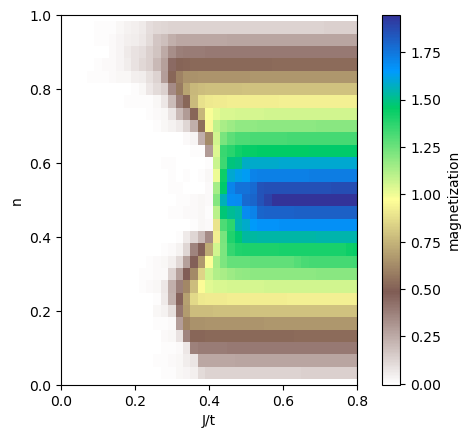

In [25]:
# the magnetizartion
array_magnetization = np.array(
    [[params["m"] for params in x] for x in d["params"]]
)  # .shape (filling, Js, vertices)

fig, ax = plt.subplots(1, 1)

# ax.set_title('T/t={0}; Lq={1}'.format(T,Lq))
ax.set_xlabel("J/t")
ax.set_ylabel("n")
ax.set_xlim(Js[0], Js[-1])
ax.set_ylim(ns[0], ns[-1])

extent = [
    Js[0] - (Js[1] - Js[0]) / 2,
    Js[-1] + (Js[1] - Js[0]) / 2,
    ns[0] - (ns[1] - ns[0]) / 2,
    ns[-1] + (ns[1] - ns[0]) / 2,
]  # the correct extent

im = ax.imshow(
    array_magnetization.mean(axis=-1),
    origin="lower",
    interpolation="none",
    extent=extent,
    cmap="terrain_r",
)
cbar = fig.colorbar(im, ax=ax, shrink=1)
cbar.set_label("magnetization")

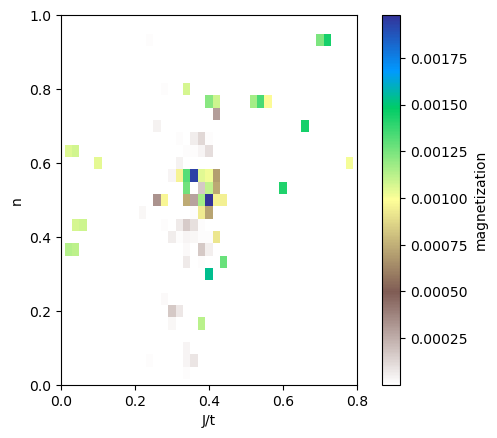

In [5]:
# check convergence

iterations = np.array(
    [
        [params["numerical_param"]["m_values"].shape[0] for params in x]
        for x in d["data"]
    ]
)  # .shape (filling, Js, vertices)
diffs = np.array(
    [
        [
            params["numerical_param"]["m_values"][-2]
            - params["numerical_param"]["m_values"][-1]
            for params in x
        ]
        for x in d["data"]
    ]
)  # .shape (filling, Js, vertices)
diffs = np.abs(diffs).mean(axis=-1)

fig, ax = plt.subplots(1, 1)

# ax.set_title('T/t={0}; Lq={1}'.format(T,Lq))
ax.set_xlabel("J/t")
ax.set_ylabel("n")
ax.set_xlim(Js[0], Js[-1])
ax.set_ylim(ns[0], ns[-1])

extent = [
    Js[0] - (Js[1] - Js[0]) / 2,
    Js[-1] + (Js[1] - Js[0]) / 2,
    ns[0] - (ns[1] - ns[0]) / 2,
    ns[-1] + (ns[1] - ns[0]) / 2,
]  # the correct extent

im = ax.imshow(
    diffs, origin="lower", interpolation="none", extent=extent, cmap="terrain_r"
)
cbar = fig.colorbar(im, ax=ax, shrink=1)
cbar.set_label("magnetization")

In [6]:
# calculate spin conductance

lattice = pickle.load(open("voronoi_20.pickle", "rb"))


lead_symmetry = np.diag([-1, -1, 1, 1])
for data_column in tqdm(d["data"]):
    for data_entry in data_column:

        hamiltonian = alt_hamiltonian(
            lattice,
            data_entry["hparam"]["t1"],
            data_entry["hparam"]["t2"],
            data_entry["hparam"]["J"],
            data_entry["hparam"]["J"],
            data_entry["hparam"]["m"],
            data_entry["hparam"]["n"],
            theta_offset=data_entry["hparam"]["theta_offset"],
        )

        # evaluating the Fermi energy
        energies, states = la.eigh(hamiltonian)
        fermi_occupation = (
            np.linspace(0, 1, len(states)) <= data_entry["hparam"]["filling"]
        )
        local_densities = np.sum(states * states.conj() * fermi_occupation, axis=1)

        n_orbitals = 4
        lead_onsite = np.eye(n_orbitals)
        lead_coupling = np.eye(n_orbitals)

        contact_lattice, k_lattice, k_system, contact_vertices = (
            crack_hamiltonian_for_contacts_kwant(lattice, hamiltonian)
        )
        kwant_system_with_leads, left_lead, right_lead = attach_leads_to_cracked(
            contact_lattice,
            k_lattice,
            k_system,
            contact_vertices,
            lead_onsite,
            lead_coupling,
            lead_symmetry,
        )

        k_system_f = k_system.finalized()
        smatrix = kwant.smatrix(k_system_f)
        g = np.array(
            [[smatrix.transmission((1, j), (0, i)) for j in range(2)] for i in range(2)]
        )
        data_entry["spin_cond"] = g
pickle.dump(d, open(os.getcwd()[:-8] + data_name, "wb"))

  0%|          | 0/31 [00:20<?, ?it/s]


KeyboardInterrupt: 

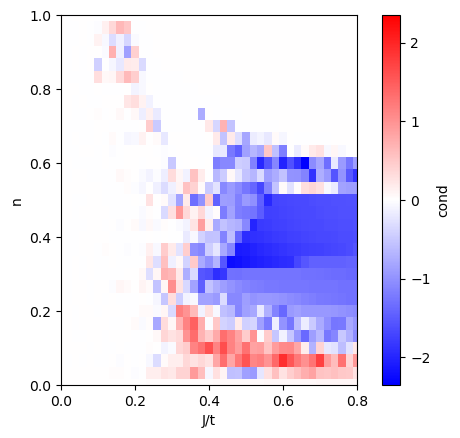

In [26]:
# the spin_cond
array_spin_cond = np.array(
    [[params["spin_cond"] for params in x] for x in d["data"]]
)  # .shape (filling, Js, 2,2)
array_g0 = array_spin_cond[:, :, 0, 0] + array_spin_cond[:, :, 1, 1]
array_gspin = array_spin_cond[:, :, 0, 0] - array_spin_cond[:, :, 1, 1]

fig, ax = plt.subplots(1, 1)

# ax.set_title('T/t={0}; Lq={1}'.format(T,Lq))
ax.set_xlabel("J/t")
ax.set_ylabel("n")
ax.set_xlim(Js[0], Js[-1])
ax.set_ylim(ns[0], ns[-1])

extent = [
    Js[0] - (Js[1] - Js[0]) / 2,
    Js[-1] + (Js[1] - Js[0]) / 2,
    ns[0] - (ns[1] - ns[0]) / 2,
    ns[-1] + (ns[1] - ns[0]) / 2,
]  # the correct extent
vabs = np.abs(array_gspin).max()

im = ax.imshow(
    array_gspin,
    origin="lower",
    interpolation="none",
    extent=extent,
    cmap="bwr",
    vmin=-vabs,
    vmax=vabs,
)
cbar = fig.colorbar(im, ax=ax, shrink=1)
cbar.set_label("cond")

In [57]:
g_spin = []
gs = []
fermi_energies = []
spectrals = []; spin_spectrals = []
idx_n = 6
print("n=", ns[idx_n])

for j in tqdm(range(0,d["data"].shape[1],2)):

    data_entry = d["data"][idx_n, j]

    hamiltonian = alt_hamiltonian(
        lattice,
        data_entry["hparam"]["t1"],
        data_entry["hparam"]["t2"],
        data_entry["hparam"]["J"],
        data_entry["hparam"]["U"],
        data_entry["hparam"]["m"],
        data_entry["hparam"]["n"],
        theta_offset=data_entry["hparam"]["theta_offset"],
    )

    # evaluating the Fermi energy
    energies, states = la.eigh(hamiltonian)
    fermi_energy = energies[
        int(data_entry["hparam"]["filling"] * len(energies))
    ]  # better algorithm to get Fermi energy

    n_orbitals = 4
    lead_onsite = np.zeros((n_orbitals,n_orbitals))
    lead_coupling = -np.eye(n_orbitals)

    contact_lattice, k_lattice, k_system, contact_vertices = (
        crack_hamiltonian_for_contacts_kwant(lattice, hamiltonian)
    )
    kwant_system_with_leads, left_lead, right_lead = attach_leads_to_cracked(
        contact_lattice,
        k_lattice,
        k_system,
        contact_vertices,
        lead_onsite,
        lead_coupling,
        lead_symmetry,
    )

    ##evaluate at fermi_energie!

    k_system_f = k_system.finalized()
    smatrix = kwant.smatrix(k_system_f, energy=fermi_energy)
    g = np.array(
        [[smatrix.transmission((1, j), (0, i)) for j in range(2)] for i in range(2)]
    )

    g_spin.append(g[0, 0] - g[1, 1])
    gs.append(g[0, 0] + g[1, 1])
    fermi_energies.append(fermi_energy)

    spectrals.append(
        spectral_function(
            lattice,
            energies,
            states,
            fermi_energy,
            local_operator=np.array([1, 1, 1, 1]),
            eta=1e-2,
            n_k=50,
        )
    )
    spin_spectrals.append(
        spectral_function(
            lattice,
            energies,
            states,
            fermi_energy,
            local_operator=np.array([1, 1, -1, -1]),
            eta=1e-2,
            n_k=50,
        )
    )


# print(g)

n= 0.2


100%|██████████| 21/21 [01:03<00:00,  3.04s/it]


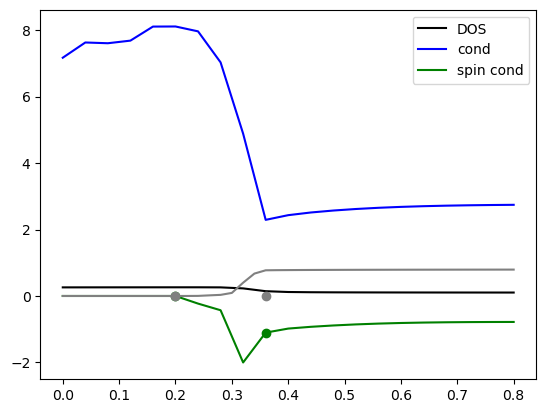

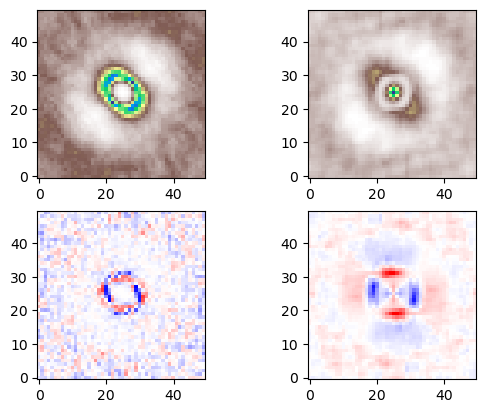

In [56]:
Js_new = Js[::2]

for x in [spectrals, fermi_energies, g_spin, Js]:
    x = np.array(x)
g_spin = np.array(g_spin)

idx_Js = np.array([5,9], dtype=int)

plt.plot(Js_new, np.mean(spectrals,axis=(1,2)), "k",label='DOS')
plt.plot(Js_new, gs, "b",label='cond')

plt.plot(Js_new, g_spin, "g",label='spin cond')
plt.plot(Js_new[idx_Js], g_spin[idx_Js], "go")

# plt.plot(Js,fermi_energies)
plt.plot(Js, array_magnetization[idx_n].mean(axis=-1), color="gray")
plt.plot(Js_new[idx_Js], array_magnetization[idx_n, idx_Js].mean(axis=-1), "o",color="gray")
plt.legend()


fig, axs = plt.subplots(2, len(idx_Js))

for j, idx_J in enumerate(idx_Js):
    
    axs[0, j].imshow(
        spectrals[idx_J],
        cmap="terrain_r",
        origin="lower")
    
    vabs=np.abs(spin_spectrals[idx_J]).max()
    axs[1, j].imshow(
        spin_spectrals[idx_J],
        cmap="bwr",
        origin="lower",vmin=-vabs,vmax=vabs)


1.5283519828430514


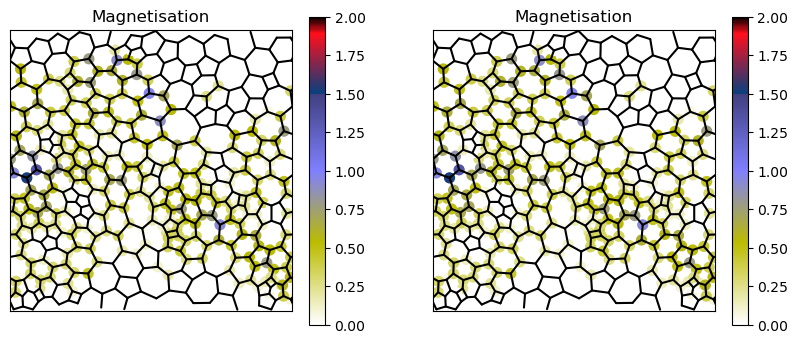

In [130]:
from koala import plotting as pl

idx_Js = np.array([16, 17], dtype=int)

dm = (
    100
    * (array_magnetization[idx_n, idx_Js[1]] - array_magnetization[idx_n, idx_Js[0]])
    / 2
)
print(dm.max())


fig, axs = plt.subplots(1, len(idx_Js), figsize=(len(idx_Js) * 5, 4))
for idx_J, ax in zip(idx_Js, axs):
    pl.plot_edges(lattice, ax=ax)
    im = ax.scatter(
        lattice.vertices.positions[:, 0],
        lattice.vertices.positions[:, 1],
        c=dm,  # array_magnetization[idx_n,idx_J],
        cmap="gist_stern_r",
        s=50,
        vmin=0,
        vmax=2,
    )
    plt.colorbar(im, ax=ax)
    ax.set_aspect("equal")
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_title("Magnetisation")